In [1]:
import sys
from pathlib import Path

# This finds the parent directory of your notebook (the project root)
root_path = Path.cwd().parent
if str(root_path) not in sys.path:
    sys.path.append(str(root_path))

# Import the loader and the processor
from src.loader.data_loader import get_merged_data
from src.preprocessing.features import DisasterDataProcessor

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.max_columns", None)
import warnings
warnings.filterwarnings('ignore')

In [3]:
# 1. Fetch the raw merged data
decl_df, summaries_df, nri_df, pop_df = get_merged_data(path_to_data="../data")
nri_df = pd.read_csv(r"../data/external/NRI_Table_Counties.csv")
pop_df = pd.read_csv(r"../data/external/historical_county_populations.csv")

# 2. Initialize the processor
processor = DisasterDataProcessor(nri_df, pop_df)

# 3. Run the full pipeline (Cleaning, Imputing, Engineering, and Filtering)
df = processor.run_training_pipeline(decl_df, summaries_df)

# Verify the result
print(f"Final shape for EDA: {df.shape}")
df.isna().sum()

DEBUG: Threshold 1.5 | Before: 2864 | After: 2467
Final shape for EDA: (2467, 39)


disasterNumber                    0
totalObligatedAmountPa            0
totalObligatedAmountCatAb       283
totalObligatedAmountCatC2g     1125
totalAmountIhpApproved            0
totalObligatedAmountHmgp          0
totalNumberIaApproved          2029
state                             0
declarationType                   0
fyDeclared                        0
designatedArea                    0
incidentType                      0
declarationDate                   0
incidentBeginDate                 0
incidentEndDate                   0
population                        0
BUILDVALUE                        0
AGRIVALUE                         0
RISK_SCORE                       85
EAL_SCORE                        27
SOVI_SCORE                       85
ihProgramDeclared                 0
iaProgramDeclared                 0
paProgramDeclared                 0
hmProgramDeclared                 0
tribalRequest                     0
countiesAffected                  0
incident_duration_days      

In [20]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2851 entries, 0 to 2850
Data columns (total 39 columns):
 #   Column                       Non-Null Count  Dtype         
---  ------                       --------------  -----         
 0   disasterNumber               2851 non-null   int64         
 1   totalObligatedAmountPa       2851 non-null   float64       
 2   totalObligatedAmountCatAb    2483 non-null   float64       
 3   totalObligatedAmountCatC2g   1460 non-null   float64       
 4   totalAmountIhpApproved       2851 non-null   float64       
 5   totalObligatedAmountHmgp     2851 non-null   float64       
 6   totalNumberIaApproved        580 non-null    float64       
 7   state                        2851 non-null   object        
 8   declarationType              2851 non-null   object        
 9   fyDeclared                   2851 non-null   int64         
 10  designatedArea               2851 non-null   float64       
 11  incidentType                 2851 non-null 

In [4]:
df = df.drop(columns=['totalObligatedAmountCatAb', 'totalObligatedAmountCatC2g', 'totalNumberIaApproved'])

df

,disasterNumber,totalObligatedAmountPa,totalAmountIhpApproved,totalObligatedAmountHmgp,state,declarationType,fyDeclared,designatedArea,incidentType,declarationDate,incidentBeginDate,incidentEndDate,population,BUILDVALUE,AGRIVALUE,RISK_SCORE,EAL_SCORE,SOVI_SCORE,ihProgramDeclared,iaProgramDeclared,paProgramDeclared,hmProgramDeclared,tribalRequest,countiesAffected,incident_duration_days,incident_to_dec_lag,month_declared,incident_type_grouped,total_recovery_cost,total_recovery_cost_adj,log_total_recovery_cost_adj,log_incident_duration_days,log_incident_to_dec_lag,log_population,log_BUILDVALUE,log_AGRIVALUE
0,1981,2.243558e+08,95754618.67,71549737.00,ND,DR,2011,44.0,Flood,2011-05-10,2011-02-14,2011-07-20,629082.0,2.526910e+11,9.765152e+09,23.916406,27.447823,32.762983,1.0,0,1,1,0,44.0,156.0,85.0,5.0,Flood,3.916601e+08,5.461902e+08,20.118478,5.056246,4.454347,13.352018,26.255433,23.002086
1,1802,1.881275e+07,0.00,2710679.00,KY,DR,2009,35.0,Severe Storm,2008-10-09,2008-09-12,2008-09-14,1774644.0,4.302201e+11,3.194606e+09,50.176300,48.887023,54.686478,0.0,0,1,1,0,35.0,2.0,27.0,10.0,Severe Storm,2.152343e+07,3.147085e+07,17.264572,1.098612,3.332205,14.389111,26.787563,21.884730
2,4317,7.731984e+07,12527583.31,17801245.73,MO,DR,2017,55.0,Flood,2017-06-02,2017-04-28,2017-05-11,3155705.0,7.754416e+11,5.428948e+09,60.629771,59.481886,49.446565,1.0,0,1,1,0,55.0,13.0,35.0,6.0,Flood,1.076487e+08,1.377619e+08,18.741038,2.639057,3.583519,14.964723,27.376699,22.415011
3,1292,2.981058e+08,0.00,67665966.00,NC,DR,1999,66.0,Hurricane,1999-09-16,1999-09-15,1999-11-02,4493219.0,1.487606e+12,1.412934e+10,69.303242,65.452952,60.311127,0.0,1,1,1,0,66.0,48.0,1.0,9.0,Hurricane,3.657718e+08,6.887069e+08,20.350326,3.891820,0.693147,15.318080,28.028189,23.371519
4,1255,4.507775e+06,0.00,844215.00,WA,DR,1999,1.0,Mud/Landslide,1998-10-16,1998-03-06,1998-11-19,82119.0,2.483287e+10,2.441504e+07,90.298982,89.573020,36.195929,0.0,1,1,1,0,1.0,258.0,140.0,10.0,Other,5.351990e+06,1.007719e+07,16.125785,5.556828,4.948760,11.315937,23.935434,17.010710
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2846,2513,4.568546e+04,0.00,0.00,SD,FM,2004,1.0,Fire,2003-11-20,2003-11-20,2003-11-21,88565.0,2.148039e+10,7.783914e+07,78.562341,80.136139,34.637405,0.0,0,1,0,0,1.0,1.0,0.0,11.0,Fire,4.568546e+04,7.586568e+04,11.236733,0.693147,0.000000,11.391503,23.790406,18.170155
2847,2651,5.347080e+04,0.00,0.00,TX,FM,2006,1.0,Fire,2006-06-27,2006-06-27,2006-07-22,432976.0,1.774161e+11,1.586493e+08,96.914758,98.267327,10.623410,0.0,0,1,0,0,1.0,25.0,0.0,6.0,Fire,5.347080e+04,8.320041e+04,11.329020,3.258097,0.000000,12.978440,25.901764,18.882207
2848,2372,1.707297e+06,0.00,0.00,WA,FM,2001,1.0,Fire,2001-08-14,2001-08-13,2001-08-29,39564.0,1.056524e+10,4.353087e+08,89.185751,84.034653,88.963104,0.0,0,1,0,0,1.0,16.0,1.0,8.0,Fire,1.707297e+06,3.024055e+06,14.922110,2.833213,0.693147,10.585700,23.080835,19.891566
2849,2567,1.682446e+05,0.00,0.00,NV,FM,2005,1.0,Fire,2005-07-16,2005-07-15,2005-07-21,45291.0,1.252199e+10,9.294317e+07,87.913486,88.242574,28.498728,0.0,0,1,0,0,1.0,6.0,1.0,7.0,Fire,1.682446e+05,2.702329e+05,12.507043,1.945910,0.693147,10.720886,23.250752,18.347499


In [9]:
df[df['state'] == 'ND'][['state', 'fyDeclared', 'countiesAffected', 'population', 'BUILDVALUE', 'RISK_SCORE']].sort_values(by='fyDeclared').head()

,state,fyDeclared,countiesAffected,population,BUILDVALUE,RISK_SCORE
768,ND,1999,43.0,592510.0,2.521623e+11,25.120569
1735,ND,2000,40.0,567489.0,2.252543e+11,23.662532
1246,ND,2001,37.0,501414.0,1.971235e+11,22.441717
1999,ND,2001,9.0,59684.0,4.084969e+10,17.341674
2357,ND,2002,5.0,117468.0,4.089745e+10,32.996183


In [18]:
df['total_recovery_cost_adj'].max()

np.float64(7785301275.6610565)

In [17]:
df.sort_values(by='total_recovery_cost_adj').head(30)

,disasterNumber,totalObligatedAmountPa,totalAmountIhpApproved,totalObligatedAmountHmgp,state,declarationType,fyDeclared,designatedArea,incidentType,declarationDate,incidentBeginDate,incidentEndDate,population,BUILDVALUE,AGRIVALUE,RISK_SCORE,EAL_SCORE,SOVI_SCORE,ihProgramDeclared,iaProgramDeclared,paProgramDeclared,hmProgramDeclared,tribalRequest,countiesAffected,incident_duration_days,incident_to_dec_lag,month_declared,incident_type_grouped,total_recovery_cost,total_recovery_cost_adj,log_total_recovery_cost_adj,log_incident_duration_days,log_incident_to_dec_lag,log_population,log_BUILDVALUE,log_AGRIVALUE
1310,5016,3135.26,0.0,0.0,MT,FM,2012,1.0,Fire,2012-09-11,2012-09-10,2012-09-16,40212.0,1.020680e+10,5.492069e+07,78.466921,77.877475,45.197201,0.0,0,1,0,0,1.0,6.0,1.0,9.0,Fire,3135.26,4283.633606,8.362790,1.945910,0.693147,10.601946,23.046320,17.821401
1613,5398,3783.95,0.0,0.0,WA,FM,2021,1.0,Fire,2021-07-14,2021-07-13,2021-07-20,79074.0,2.150889e+10,3.327524e+08,90.871501,89.603960,48.632316,0.0,0,1,1,0,1.0,7.0,1.0,7.0,Fire,3783.95,4380.497810,8.385146,2.079442,0.693147,11.278152,23.791732,19.622909
2782,3341,3194.36,0.0,0.0,NY,EM,2011,15.0,Severe Storm,2011-09-08,2011-09-07,2011-09-11,1628764.0,3.683314e+11,8.819100e+08,71.488550,71.165429,49.465649,0.0,0,1,0,0,15.0,4.0,1.0,9.0,Severe Storm,3194.36,4454.699248,8.401939,1.609438,0.693147,14.303333,26.632249,20.597601
94,5230,3811.30,0.0,0.0,OK,FM,2018,1.0,Fire,2018-03-16,2018-03-16,2018-03-16,69442.0,9.860988e+09,4.197090e+07,82.315522,77.722772,75.031807,0.0,0,1,1,0,1.0,0.0,0.0,3.0,Fire,3811.30,4761.169086,8.468459,0.000000,0.000000,11.148262,23.011852,17.552487
654,2639,3338.02,0.0,0.0,TX,FM,2006,1.0,Fire,2006-05-26,2006-05-26,2006-06-20,354452.0,1.559894e+11,1.094937e+08,97.455471,98.143564,16.984733,0.0,0,1,0,0,1.0,25.0,0.0,5.0,Fire,3338.02,5193.949185,8.555442,3.258097,0.000000,12.778331,25.773054,18.511377
851,2675,3584.55,0.0,0.0,TX,FM,2006,1.0,Fire,2006-09-14,2006-09-14,2006-10-09,812280.0,2.127681e+11,3.619537e+07,97.741730,98.514851,14.758270,0.0,0,1,0,0,1.0,25.0,0.0,9.0,Fire,3584.55,5577.549132,8.626684,3.258097,0.000000,13.607602,26.083469,17.404442
2746,5169,4523.54,0.0,0.0,OK,FM,2017,1.0,Fire,2017-02-23,2017-02-23,2017-03-20,73085.0,1.232440e+10,5.917784e+07,73.250636,76.206683,28.371501,0.0,0,1,1,0,1.0,25.0,0.0,2.0,Fire,4523.54,5788.939046,8.663877,3.258097,0.000000,11.199392,23.234847,17.896058
2025,2872,4527.53,0.0,0.0,OK,FM,2011,1.0,Fire,2011-03-12,2011-03-12,2011-03-15,69442.0,9.860988e+09,4.197090e+07,82.315522,77.722772,75.031807,0.0,0,1,0,0,1.0,3.0,0.0,3.0,Fire,4527.53,6313.873353,8.750663,1.386294,0.000000,11.148262,23.011852,17.552487
2491,2489,3864.97,0.0,0.0,MT,FM,2003,1.0,Fire,2003-08-12,2003-08-10,2003-08-24,10227.0,3.434079e+09,2.177023e+07,47.360051,31.095297,96.246819,0.0,0,1,0,0,1.0,14.0,2.0,8.0,Fire,3864.97,6589.122687,8.793327,2.708050,1.098612,9.232884,21.957015,16.896054
950,5410,5834.27,0.0,0.0,WA,FM,2021,1.0,Fire,2021-08-16,2021-08-15,2021-09-01,42104.0,1.056524e+10,4.353087e+08,89.185751,84.034653,88.963104,0.0,0,1,1,0,1.0,17.0,1.0,8.0,Fire,5834.27,6754.055143,8.818046,2.890372,0.693147,10.647922,23.080835,19.891566


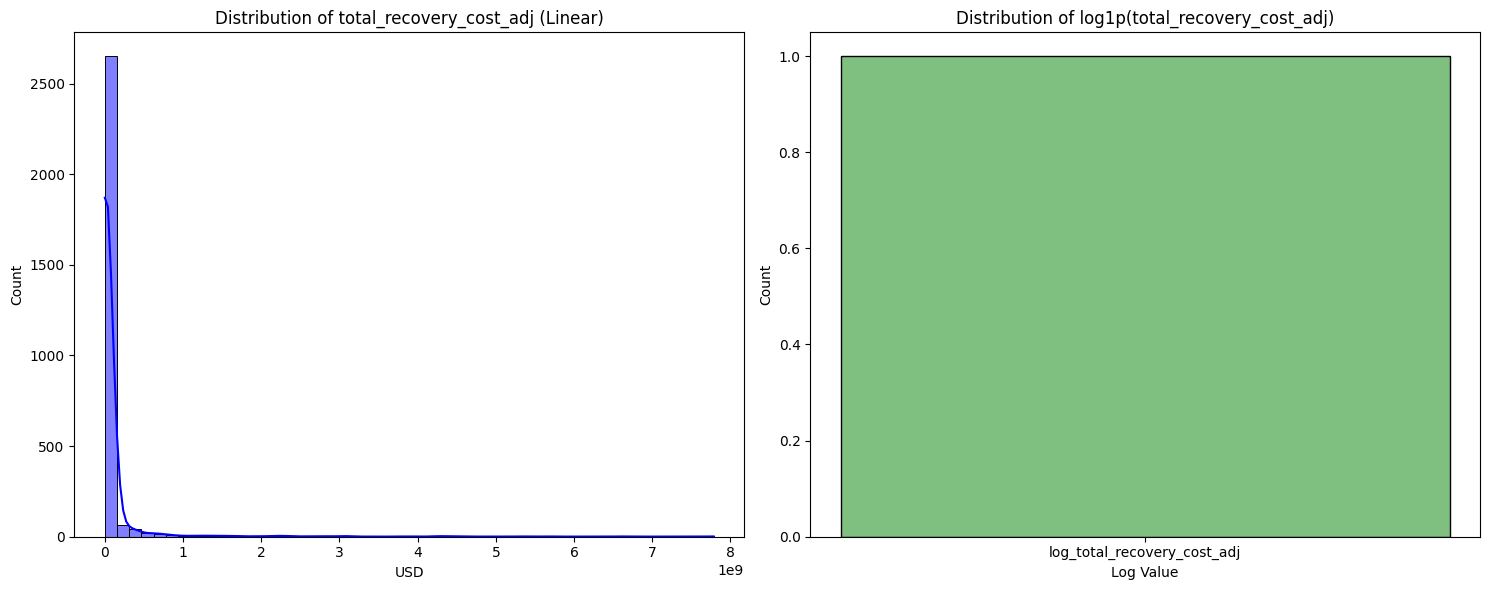


--- Target Statistics (Adjusted Dollars) ---
count    2.851000e+03
mean     8.305203e+07
std      4.090957e+08
min      4.283634e+03
25%      1.447847e+06
50%      6.760916e+06
75%      2.581806e+07
max      7.785301e+09
Name: total_recovery_cost_adj, dtype: float64

Skewness (Linear): 10.11
Skewness (Log): -0.15


In [12]:
target_col='total_recovery_cost_adj'
log_target = 'log_total_recovery_cost_adj'


# Create side-by-side plots
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

# Plot 1: Linear Scale (The 'Real Dollar' view)
sns.histplot(df[target_col], bins=50, kde=True, ax=ax1, color='blue')
ax1.set_title(f'Distribution of {target_col} (Linear)')
ax1.set_xlabel('USD')

# Plot 2: Log Scale (The 'Model' view)
sns.histplot(log_target, bins=50, kde=True, ax=ax2, color='green')
ax2.set_title(f'Distribution of log1p({target_col})')
ax2.set_xlabel('Log Value')

plt.tight_layout()
plt.show()

# Output detailed summary statistics
print("\n--- Target Statistics (Adjusted Dollars) ---")
print(df[target_col].describe())
print(f"\nSkewness (Linear): {df[target_col].skew():.2f}")
print(f"Skewness (Log): {df[log_target].skew():.2f}")

In [7]:
nri_df[nri_df['RISK_SCORE'].isna()][['RISK_SCORE', 'SOVI_SCORE','EAL_SCORE', 'STATE']]

,RISK_SCORE,SOVI_SCORE,EAL_SCORE,STATE
3135,NaN,NaN,81.992574,American Samoa
3136,NaN,NaN,2.629950,American Samoa
3137,NaN,NaN,55.785891,American Samoa
3138,NaN,NaN,96.287129,Guam
3139,NaN,NaN,4.269802,Northern Mariana Islands
...,...,...,...,...
3218,NaN,NaN,64.016089,Puerto Rico
3219,NaN,NaN,70.482673,Puerto Rico
3220,NaN,NaN,87.097772,Virgin Islands
3221,NaN,NaN,20.544554,Virgin Islands


In [16]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 3079 entries, 0 to 3078
Data columns (total 14 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   disasterNumber              3079 non-null   int64  
 1   declarationType             3079 non-null   str    
 2   stateCode                   3079 non-null   str    
 3   region                      3079 non-null   int64  
 4   iaProgramDeclared           3079 non-null   int64  
 5   paProgramDeclared           3079 non-null   int64  
 6   hmProgramDeclared           3079 non-null   int64  
 7   total_recovery_cost         3079 non-null   float64
 8   log_total_cost              3079 non-null   float64
 9   month_declared              3079 non-null   int32  
 10  incident_type_grouped       3079 non-null   str    
 11  log_incident_duration_days  3079 non-null   float64
 12  log_request_to_dec_lag      3079 non-null   float64
 13  log_incident_to_dec_lag     3079 non-null   

In [8]:
df.columns

Index(['disasterNumber', 'declarationType', 'stateCode', 'region',
       'iaProgramDeclared', 'paProgramDeclared', 'hmProgramDeclared',
       'total_recovery_cost', 'log_total_cost', 'incident_duration_days',
       'request_to_dec_lag', 'incident_to_dec_lag', 'month_declared',
       'incident_type_grouped'],
      dtype='str')

In [4]:
df['incident_type_grouped'].value_counts()

incident_type_grouped
Fire                1242
Severe Storm         891
Hurricane            269
Flood                244
Other                124
Snowstorm            118
Biological            75
Severe Ice Storm      53
Tornado               43
Typhoon               20
Name: count, dtype: int64

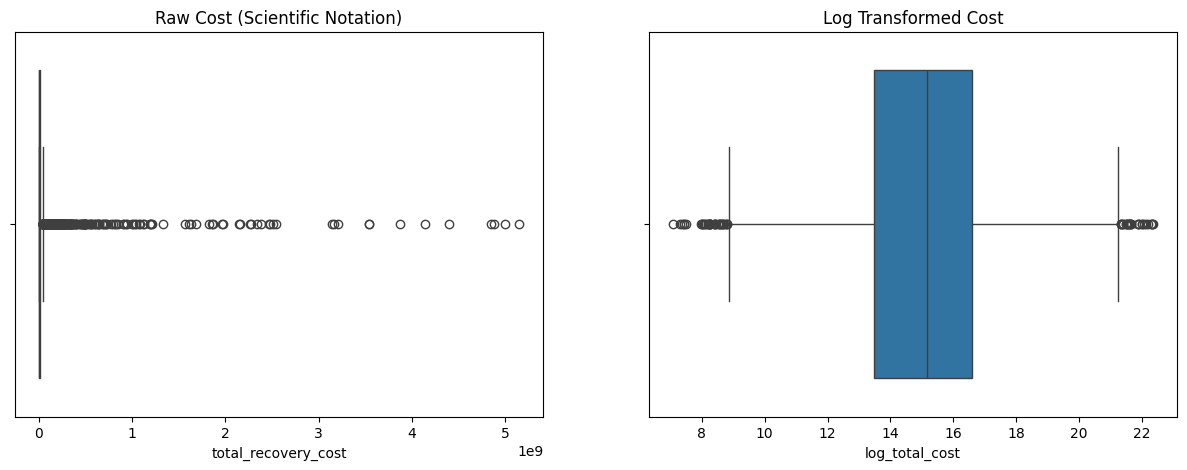

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# 1. Raw Scale
sns.boxplot(x=df['total_recovery_cost'], ax=axes[0])
axes[0].set_title('Raw Cost (Scientific Notation)')

# 2. Log Scale
sns.boxplot(x=df['log_total_cost'], ax=axes[1])
axes[1].set_title('Log Transformed Cost')

plt.show()


In [8]:
df.columns

Index(['disasterNumber', 'declarationType', 'stateCode', 'region',
       'iaProgramDeclared', 'paProgramDeclared', 'hmProgramDeclared',
       'total_recovery_cost', 'log_total_cost', 'month_declared',
       'incident_type_grouped', 'log_incident_duration_days',
       'log_request_to_dec_lag', 'log_incident_to_dec_lag'],
      dtype='str')

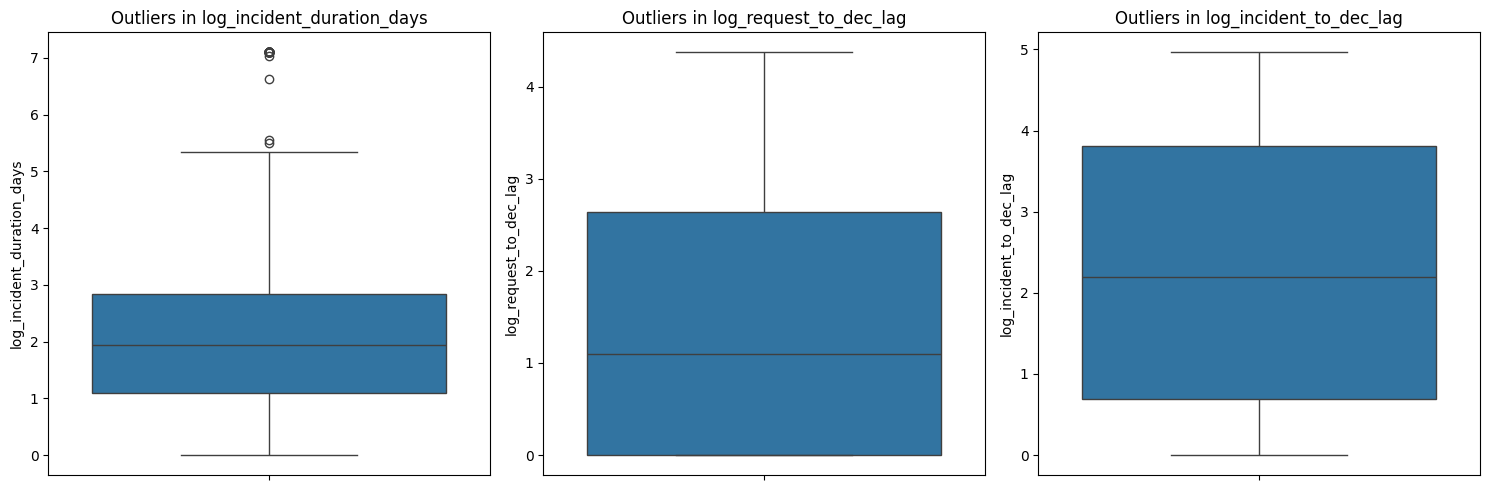

In [9]:
# List of numerical features (excluding target and categories)
numerical_features = ['log_incident_duration_days', 'log_request_to_dec_lag', 'log_incident_to_dec_lag']

plt.figure(figsize=(15, 5))
for i, col in enumerate(numerical_features, 1):
    plt.subplot(1, 3, i)
    sns.boxplot(y=df[col])
    plt.title(f'Outliers in {col}')

plt.tight_layout()
plt.show()


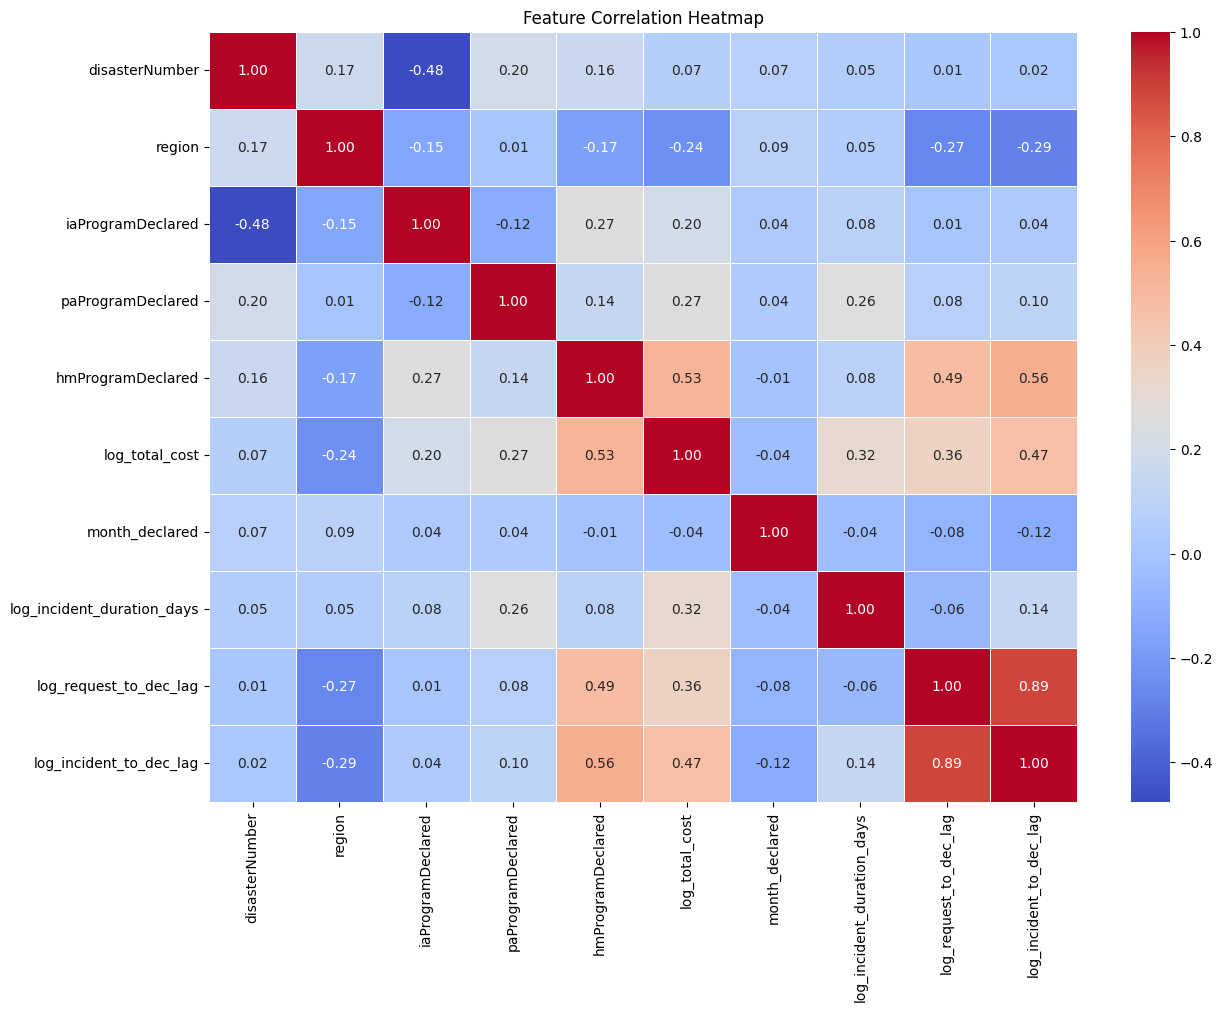

In [10]:

# 1. Select numeric columns for the correlation matrix
# Ensure categorical columns like 'stateCode' are handled separately or excluded here

numeric_df = df.drop(columns=['total_recovery_cost']).select_dtypes(include=['number'])

# 2. Compute the Pearson correlation matrix
corr_matrix = numeric_df.corr()

# 3. Create the heatmap
plt.figure(figsize=(14, 10))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title('Feature Correlation Heatmap')
plt.show()


In [6]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

# 1. Select only the numerical features engineered
# VIF requires a constant (intercept) to be added for accurate calculation
X_vif = df[['incident_duration_days', 'request_to_dec_lag', 'incident_to_dec_lag']].copy()
X_vif['intercept'] = 1 

# 2. Calculate VIF for each feature
vif_data = pd.DataFrame()
vif_data["feature"] = X_vif.columns
vif_data["VIF"] = [variance_inflation_factor(X_vif.values, i) 
                          for i in range(len(X_vif.columns))]

# 3. Filter out the intercept and show results
print(vif_data[vif_data['feature'] != 'intercept'].sort_values(by='VIF', ascending=False))


                  feature       VIF
2     incident_to_dec_lag  3.409318
1      request_to_dec_lag  3.248911
0  incident_duration_days  1.233513


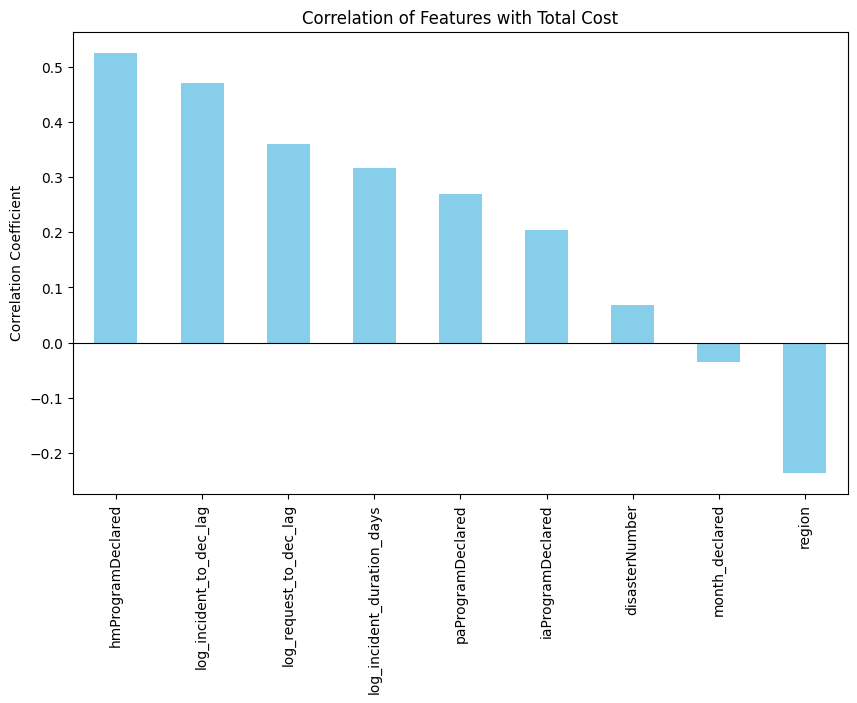

In [13]:
# 1. Calculate correlations specifically with the target
target_corr = corr_matrix['log_total_cost'].sort_values(ascending=False)

# 2. Plot the correlations
plt.figure(figsize=(10, 6))
target_corr.drop('log_total_cost').plot(kind='bar', color='skyblue')
plt.title('Correlation of Features with Total Cost')
plt.ylabel('Correlation Coefficient')
plt.axhline(0, color='black', linewidth=0.8)
plt.show()
